# Rethinking Chicago Crime Analysis

## Introduction

In this analysis, we will explore the crime data of Chicago to identify patterns and trends. We will use various data visualization techniques to gain insights into the types of crimes, their locations, and the times they occur.

## Data Collection

> Thanks to These projects:
> - https://www.kaggle.com/fahd09/eda-of-crime-in-chicago-2005-2016
> - 朱小波, 李昕, 叶信岳. 数据关联背景下芝加哥市一般盗窃案件的多维度分析[J]. 犯罪研究, 2018(4):10.

## Data Loading and Cleaning

Before we can analyze the data, we need to preprocess it. This includes handling missing values, converting data types, and creating new features if necessary.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gc

In [20]:
Crime_2001_to_2004 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2001_to_2004.csv", on_bad_lines="warn")
Crime_2005_to_2007 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2005_to_2007.csv", on_bad_lines="warn")
Crime_2008_to_2011 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2008_to_2011.csv", on_bad_lines="warn")
Crime_2012_to_2017 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2012_to_2017.csv", on_bad_lines="warn")

C:\Users\hanpeng\AppData\Local\Temp\ipykernel_39756\1137305216.py:1: DtypeWarning: Columns (0: Y Coordinate, 1: Latitude) have mixed types. Specify dtype option on import or set low_memory=False.
  Crime_2001_to_2004 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2001_to_2004.csv", on_bad_lines="warn")
C:\Users\hanpeng\AppData\Local\Temp\ipykernel_39756\1137305216.py:2: ParserWarning: Skipping line 533719: expected 23 fields, saw 24

  Crime_2005_to_2007 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2005_to_2007.csv", on_bad_lines="warn")
C:\Users\hanpeng\AppData\Local\Temp\ipykernel_39756\1137305216.py:3: ParserWarning: Skipping line 1149094: expected 23 fields, saw 41

  Crime_2008_to_2011 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_20

Verify all dataframes have the same columns

In [21]:
print(Crime_2001_to_2004.columns)
print(Crime_2005_to_2007.columns)
print(Crime_2008_to_2011.columns)
print(Crime_2012_to_2017.columns)

print("All dataframes have the same columns: ",
      set(Crime_2001_to_2004.columns) == set(Crime_2005_to_2007.columns) == set(Crime_2008_to_2011.columns) == set(Crime_2012_to_2017.columns))


Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Location'],
      dtype='str')
Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Location'],
      dtype='str')
Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Location

Combine all dataframes into one for easier analysis

In [22]:
Crime_data = pd.concat([Crime_2001_to_2004, Crime_2005_to_2007, Crime_2008_to_2011, Crime_2012_to_2017], ignore_index=True)
del Crime_2001_to_2004
del Crime_2005_to_2007
del Crime_2008_to_2011
del Crime_2012_to_2017
gc.collect()
Crime_data.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,879,4786321,HM399414,01/01/2004 12:01:00 AM,082XX S COLES AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,...,7.0,46.0,06,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
1,2544,4676906,HM278933,03/01/2003 12:00:00 AM,004XX W 42ND PL,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,...,11.0,61.0,26,1173974.0,1876757.0,2003.0,04/15/2016 08:55:02 AM,41.817229,-87.637328,"(41.817229156, -87.637328162)"
2,2919,4789749,HM402220,06/20/2004 11:00:00 AM,025XX N KIMBALL AVE,1752,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,False,...,35.0,22.0,20,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
3,2927,4789765,HM402058,12/30/2004 08:00:00 PM,045XX W MONTANA ST,0840,THEFT,FINANCIAL ID THEFT: OVER $300,OTHER,False,...,31.0,20.0,06,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
4,3302,4677901,HM275615,05/01/2003 01:00:00 AM,111XX S NORMAL AVE,0841,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,...,34.0,49.0,06,1174948.0,1831051.0,2003.0,04/15/2016 08:55:02 AM,41.691785,-87.635116,"(41.691784636, -87.635115968)"


Handle duplicate entries

In [23]:
print("Before handling duplicates: ", Crime_data.shape)
Crime_data.drop_duplicates(inplace=True)
print("After handling duplicates: ", Crime_data.shape)

Before handling duplicates:  (7941282, 23)
After handling duplicates:  (6200659, 23)


Convert 'Date' column to datetime format

In [27]:
Crime_data['Date'] = pd.to_datetime(Crime_data['Date'], format="%m/%d/%Y %I:%M:%S %p")

In [28]:
Crime_data.dtypes

Unnamed: 0                       int64
ID                               int64
Case Number                        str
Date                    datetime64[us]
Block                              str
IUCR                               str
Primary Type                       str
Description                        str
Location Description               str
Arrest                            bool
Domestic                          bool
Beat                             int64
District                       float64
Ward                           float64
Community Area                 float64
FBI Code                           str
X Coordinate                   float64
Y Coordinate                    object
Year                           float64
Updated On                         str
Latitude                        object
Longitude                      float64
Location                           str
dtype: object

## Exploratory Data Analysis

### Types of Crimes

Primary Type
THEFT                                1290528
BATTERY                              1131424
CRIMINAL DAMAGE                       713582
NARCOTICS                             677868
OTHER OFFENSE                         383846
ASSAULT                               378834
BURGLARY                              363098
MOTOR VEHICLE THEFT                   292641
ROBBERY                               234577
DECEPTIVE PRACTICE                    224147
CRIMINAL TRESPASS                     178915
PROSTITUTION                           65794
WEAPONS VIOLATION                      60907
PUBLIC PEACE VIOLATION                 44920
OFFENSE INVOLVING CHILDREN             40348
CRIM SEXUAL ASSAULT                    23720
SEX OFFENSE                            22734
GAMBLING                               13913
LIQUOR LAW VIOLATION                   13512
INTERFERENCE WITH PUBLIC OFFICER       12886
ARSON                                  10352
HOMICIDE                                82

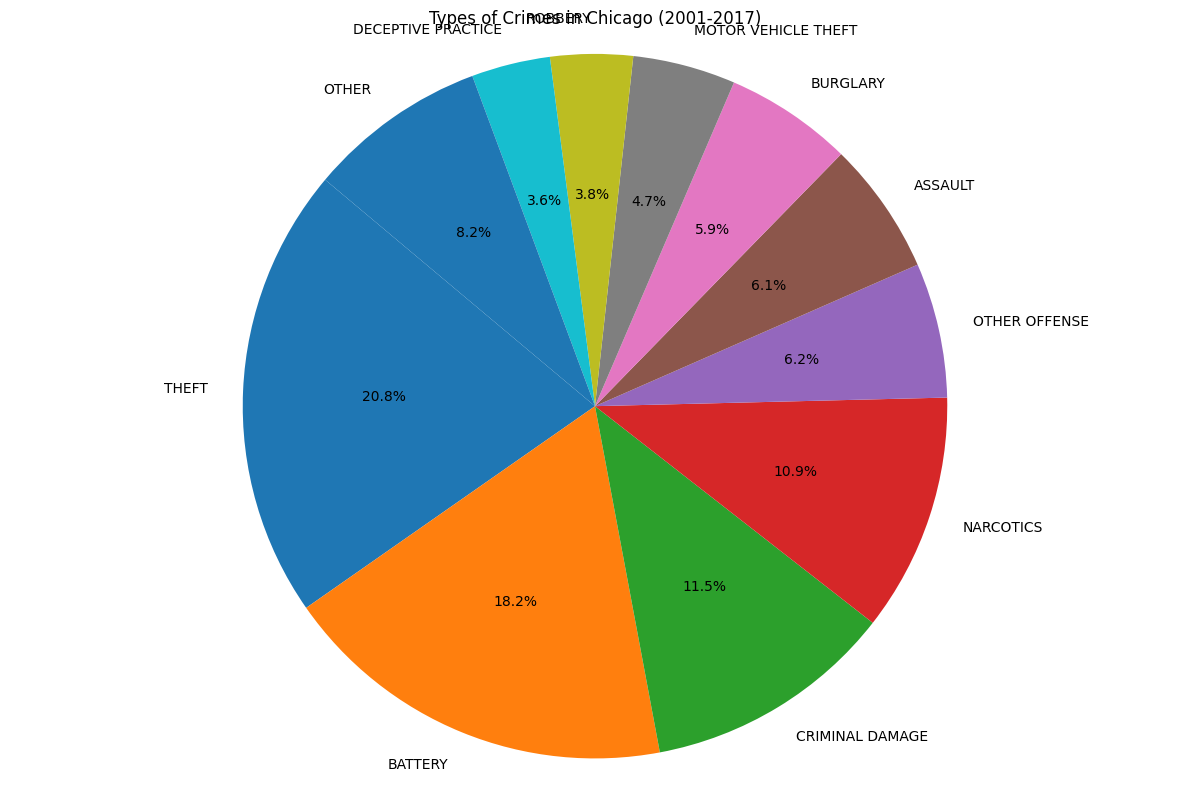

In [31]:
crime_counts = Crime_data['Primary Type'].value_counts()
print(crime_counts)

top_crimes = crime_counts.head(10)
other_count = crime_counts.iloc[10:].sum()
plot_data = pd.concat([top_crimes, pd.Series({'OTHER': other_count})])

plt.figure(figsize=(12, 8))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', startangle=140)
plt.title('Types of Crimes in Chicago (2001-2017)')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Non-geographic Missing values?

In [32]:
# Check missing values across all columns
missing_counts = Crime_data.isna().sum().sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": (missing_counts / len(Crime_data) * 100).round(2)
})

# Show only columns with missing values
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
print("Columns with missing values:\n")
print(missing_summary)

# Test whether missing data is only in geographic fields
geo_cols = {"X Coordinate", "Y Coordinate", "Latitude", "Longitude", "Location"}
non_geo_missing = [col for col in missing_summary.index if col not in geo_cols]

if not non_geo_missing:
    print("\nYes — missing values are only in geographic information columns.")
else:
    print("\nNo — there are missing values in non-geographic columns too:")
    print(non_geo_missing)

Columns with missing values:

                      missing_count  missing_pct
Community Area               645838        10.42
Ward                         644660        10.40
Location                      84224         1.36
Longitude                     84224         1.36
Latitude                      84223         1.36
X Coordinate                  84223         1.36
Y Coordinate                  84223         1.36
Location Description           1968         0.03
District                         49         0.00
Case Number                       4         0.00

No — there are missing values in non-geographic columns too:
['Community Area', 'Ward', 'Location Description', 'District', 'Case Number']


What are the case numbers that are missing?

In [33]:
missing_case_rows = Crime_data[Crime_data["Case Number"].isna()]

print(f"Number of missing case numbers: {len(missing_case_rows)}")
missing_case_rows[["ID", "Date", "Block", "Primary Type", "Case Number"]]

Number of missing case numbers: 4


,ID,Date,Block,Primary Type,Case Number
4425181,7014449,2009-07-10 11:00:00,082XX S HARPER AVE,ASSAULT,NaN
4447882,7049552,2009-07-30 03:00:00,058XX N PAULINA ST,CRIMINAL DAMAGE,NaN
4809787,7610078,2010-07-16 14:56:00,005XX W VAN BUREN ST,BATTERY,NaN
7759089,8475075,2012-02-08 22:00:00,032XX N KILDARE AVE,BURGLARY,NaN
